In [1]:
# Final organized code using HuggingFace Trainer with ELECTRA-small model

"""
This script performs binary text classification using the ELECTRA-small-discriminator model.
It includes dataset preparation, tokenization, model fine-tuning using HuggingFace's Trainer,
evaluation with performance visualizations including confusion matrix and classification report.
"""

# 1. Import Libraries
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import warnings
import json
import numpy as np
import transformers
import accelerate
import peft

warnings.filterwarnings('ignore')


C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# 2. Load Dataset
print("Loading dataset...")
df_balanced = pd.read_csv('Data/balanced_reddit_data.csv')
df_balanced['text'] = df_balanced['text'].fillna("").astype(str)

Loading dataset...


In [3]:
# 3. Split Dataset
print("Splitting dataset...")
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_balanced['text'].tolist(),
    df_balanced['label'].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df_balanced['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Training set size: {len(train_texts)}")
print(f"Validation set size: {len(val_texts)}")
print(f"Test set size: {len(test_texts)}")


Splitting dataset...
Training set size: 595819
Validation set size: 127675
Test set size: 127676


In [4]:
# 4. Load Tokenizer
print("Loading tokenizer...")
model_name = 'google/electra-small-discriminator'
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading tokenizer...


In [5]:
# 5. Tokenize Text in Batches
def batch_tokenize(texts, tokenizer, batch_size=2500, max_length=64):
    """Tokenize texts in batches for memory efficiency."""
    input_ids = []
    attention_masks = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        input_ids.append(encodings['input_ids'])
        attention_masks.append(encodings['attention_mask'])
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    return {'input_ids': input_ids, 'attention_mask': attention_masks}

print("Tokenizing data...")
train_encodings = batch_tokenize(train_texts, tokenizer)
val_encodings = batch_tokenize(val_texts, tokenizer)
test_encodings = batch_tokenize(test_texts, tokenizer)

train_labels = torch.tensor(train_labels, dtype=torch.long)
val_labels = torch.tensor(val_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)

Tokenizing data...


In [6]:
# 6. Create Custom Dataset
class RedditDataset(Dataset):
    """Custom PyTorch Dataset for Reddit data."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

print("Preparing datasets...")
train_dataset = RedditDataset(train_encodings, train_labels)
val_dataset = RedditDataset(val_encodings, val_labels)
test_dataset = RedditDataset(test_encodings, test_labels)

Preparing datasets...


In [7]:
# 7. Load Pre-trained Model
print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
model.config.problem_type = "single_label_classification"
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

Loading model...


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Li

In [8]:
# 8. Set Training Arguments
print("Setting training arguments...")
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=True,
    logging_dir='./logs',
    logging_steps=500
)

Setting training arguments...


In [9]:
# 9. Define Evaluation Metrics
def compute_metrics(pred):
    """Compute accuracy, precision, recall, and F1 score."""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [10]:
# 10. Create Trainer
print("Initializing trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

Initializing trainer...


In [11]:
# 11. Start Training
print("Starting training...")
trainer.train()

You're using a ElectraTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.177500,0.164862,0.938469,0.939341,0.926210,0.952849
2,0.148500,0.163453,0.941281,0.942229,0.927245,0.957705
3,0.131600,0.162254,0.942690,0.943478,0.930675,0.956640


TrainOutput(global_step=55860, training_loss=0.1660578113450741, metrics={'train_runtime': 4317.073, 'train_samples_per_second': 414.044, 'train_steps_per_second': 12.939, 'total_flos': 6573292867830528.0, 'train_loss': 0.1660578113450741, 'epoch': 3.0})

In [51]:
# 12. Final Evaluation on Test Set
print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

Evaluating on test set...


Plotting training curves...


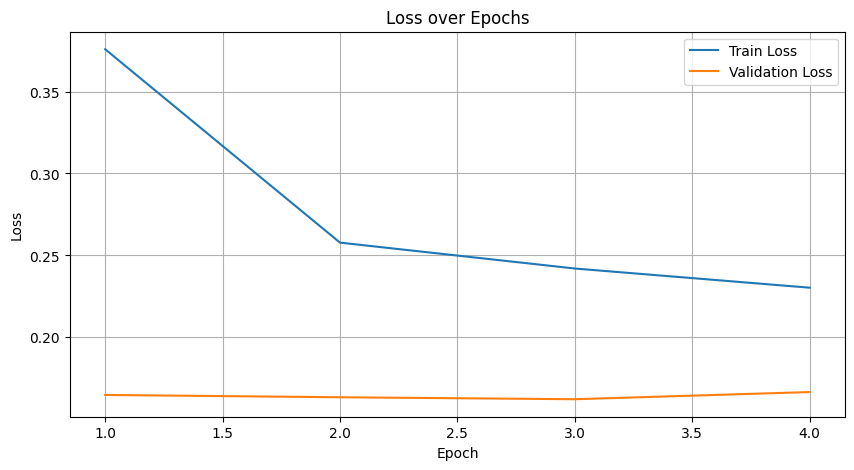

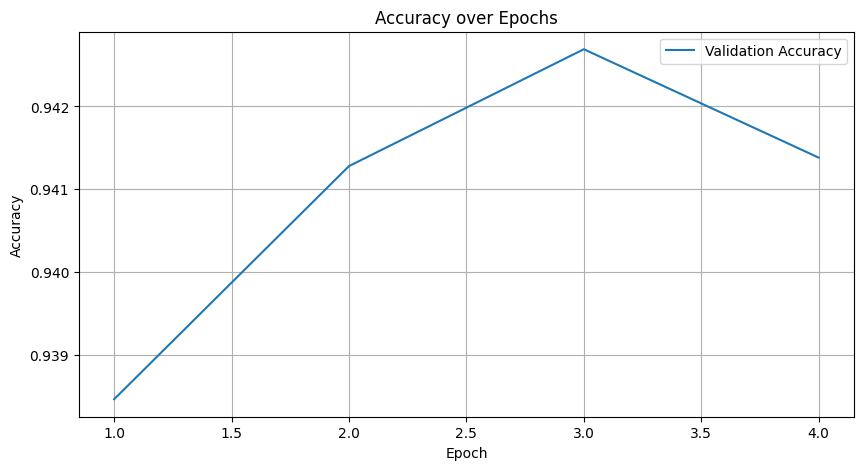

In [13]:
# 13. Plot Loss and Accuracy Curves
print("Plotting training curves...")
logs = trainer.state.log_history
train_loss = [log['loss'] for log in logs if 'loss' in log and 'epoch' in log]
eval_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]
eval_accuracy = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]
epochs = list(range(1, len(eval_loss) + 1))

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss[:len(eval_loss)], label='Train Loss')
plt.plot(epochs, eval_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, eval_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# 14. Save Evaluation Results
print("Saving evaluation results...")
with open('test_results.json', 'w') as f:
    json.dump(test_results, f, indent=4)
df_results = pd.DataFrame([test_results])
df_results.to_excel('test_results.xlsx', index=False)

Saving evaluation results...


In [17]:
# 15. Extract Predictions for Analysis
print("Extracting predictions...")
preds_output = trainer.predict(test_dataset)
all_preds = preds_output.predictions.argmax(-1)
all_labels = preds_output.label_ids

Extracting predictions...


Plotting confusion matrix...


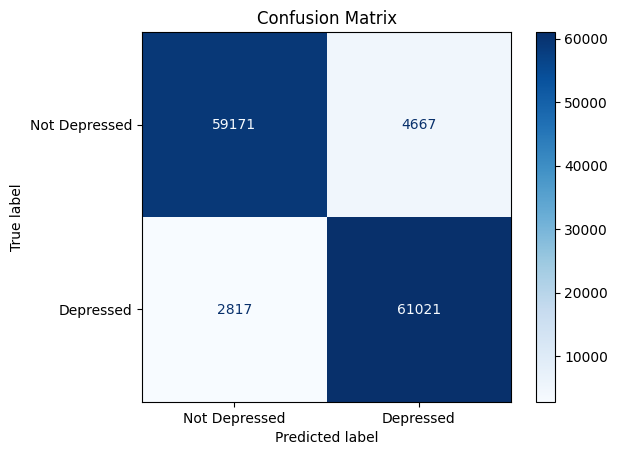

In [18]:
# 16. Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title('Confusion Matrix')
    plt.show()

print("Plotting confusion matrix...")
plot_confusion_matrix(all_labels, all_preds, class_names=['Not Depressed', 'Depressed'])

In [19]:
# 17. Print Classification Report
def print_classification_report(y_true, y_pred, class_names=None):
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)

print("Classification report:")
print_classification_report(all_labels, all_preds, class_names=['Not Depressed', 'Depressed'])

Classification report:
               precision    recall  f1-score   support

Not Depressed       0.95      0.93      0.94     63838
    Depressed       0.93      0.96      0.94     63838

     accuracy                           0.94    127676
    macro avg       0.94      0.94      0.94    127676
 weighted avg       0.94      0.94      0.94    127676



In [20]:
# 18. Show Misclassified Samples
print("Showing misclassified samples...")
def show_misclassified_samples(texts, labels, preds, num_samples=10):
    misclassified_indices = np.where(labels != preds)[0]
    num_samples = min(num_samples, len(misclassified_indices))
    sampled_indices = np.random.choice(misclassified_indices, size=num_samples, replace=False)
    data = {
        "Text": [texts[i] for i in sampled_indices],
        "True Label": [labels[i] for i in sampled_indices],
        "Predicted Label": [preds[i] for i in sampled_indices],
    }
    df = pd.DataFrame(data)
    print(df)

show_misclassified_samples(test_texts, all_labels, all_preds, num_samples=10)

Showing misclassified samples...
                                                Text  True Label  \
0  i am once again the third wheel the title says...           0   
1  its currently am and thoughts run through my m...           0   
2  you should not dislike anybody disliking someb...           0   
3  im tired of loving myself im deprived of any a...           0   
4  every step i taketheyll be watching me everywh...           0   
5  when i go to college i hope to god i dont get ...           0   
6  i quit my job in corporate to study film music...           0   
7  i saw a guy riding his bike down the street ba...           1   
8                      fuck responsibility thats all           0   
9  about suicide and suicidal intentionsfeelings ...           0   

   Predicted Label  
0                1  
1                1  
2                1  
3                1  
4                1  
5                1  
6                1  
7                0  
8                1  
9       

In [21]:
# 19. Save Model and Tokenizer
print("Saving model and tokenizer...")
save_directory = './saved_model_electra'
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)
print("Model and tokenizer saved successfully.")

print("All tasks completed successfully.")

Saving model and tokenizer...
Model and tokenizer saved successfully.
All tasks completed successfully.


In [22]:
from transformers import AutoModelForSequenceClassification

# Reload the ELECTRA model with output_attentions=True
model_with_attention = AutoModelForSequenceClassification.from_pretrained(
    './saved_model_electra', 
    output_attentions=True
)
model_with_attention.to(device)
model_with_attention.eval()

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Li

In [48]:
# Block 1: Load model and select short samples
import torch
from transformers import AutoModelForSequenceClassification
import random

# Load model
model_with_attention = AutoModelForSequenceClassification.from_pretrained(
    './saved_model_electra',  # Change path if needed
    output_attentions=True
)
model_with_attention.to(device)
model_with_attention.eval()

# Select only short samples
short_samples = [(i, text) for i, text in enumerate(test_texts) if len(text.split()) <= 20]
selected = random.sample(short_samples, 10)
sample_indices = [idx for idx, _ in selected]
sample_texts = [text for _, text in selected]
sample_true_labels = [test_labels[idx].item() for idx in sample_indices]

# Tokenize
encodings = tokenizer(
    sample_texts,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64
)
encodings = {k: v.to(device) for k, v in encodings.items()}

In [49]:
# Block 2: Forward pass
with torch.no_grad():
    outputs = model_with_attention(**encodings, output_attentions=True, return_dict=True)
    attentions = outputs.attentions
    logits = outputs.logits

# Average Attention across all layers
# attentions = list of tensors (batch, heads, seq_len, seq_len)
# First average over heads -> (batch, seq_len, seq_len)
avg_attn_per_layer = [att.mean(dim=1) for att in attentions]
# Then average over all layers -> (batch, seq_len, seq_len)
mean_attention = torch.stack(avg_attn_per_layer).mean(dim=0)

# Extract attention from CLS token
cls_attention = mean_attention[:, 0, :].detach().cpu().numpy()

# Decode tokens (cleaned)
decoded_tokens_list = []
for input_ids in encodings['input_ids']:
    tokens = tokenizer.convert_ids_to_tokens(input_ids, skip_special_tokens=True)
    tokens_clean = [token.replace('##', '') for token in tokens]  # remove subwords indicators
    decoded_tokens_list.append(tokens_clean)

# Get predicted classes
predicted_classes = logits.argmax(dim=1).detach().cpu().numpy()

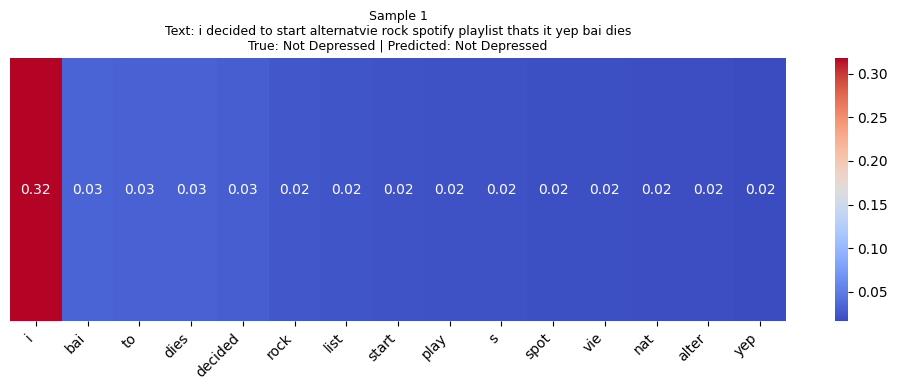

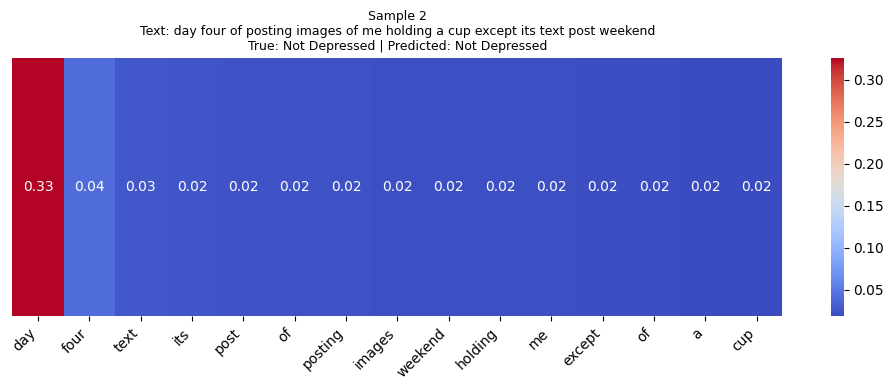

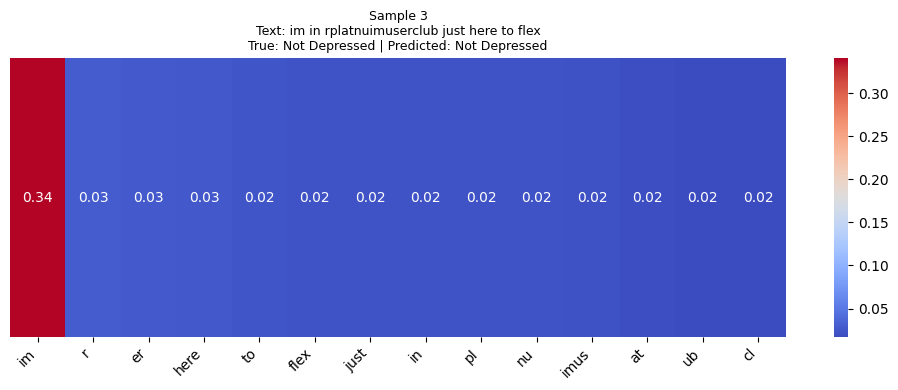

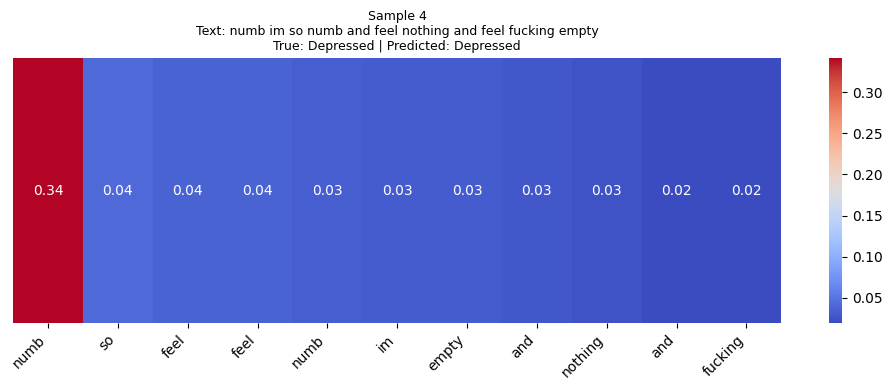

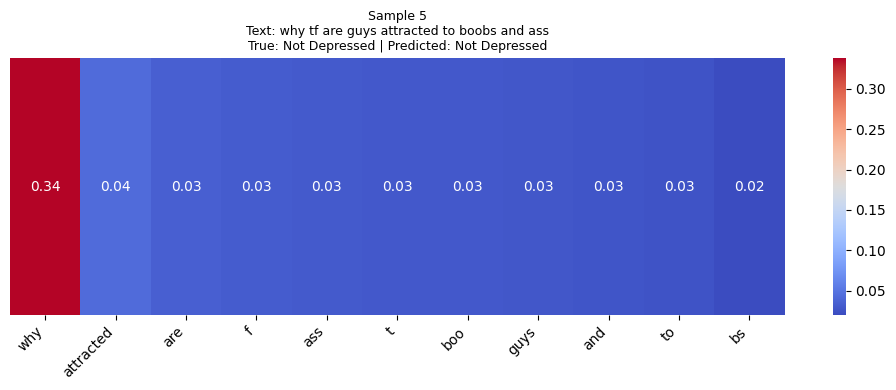

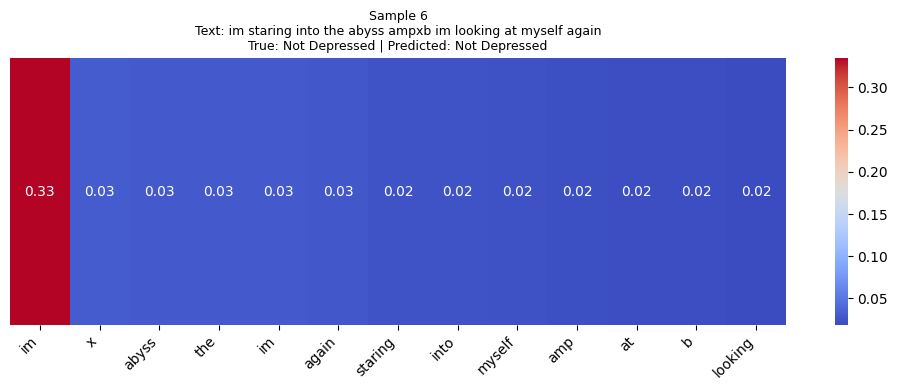

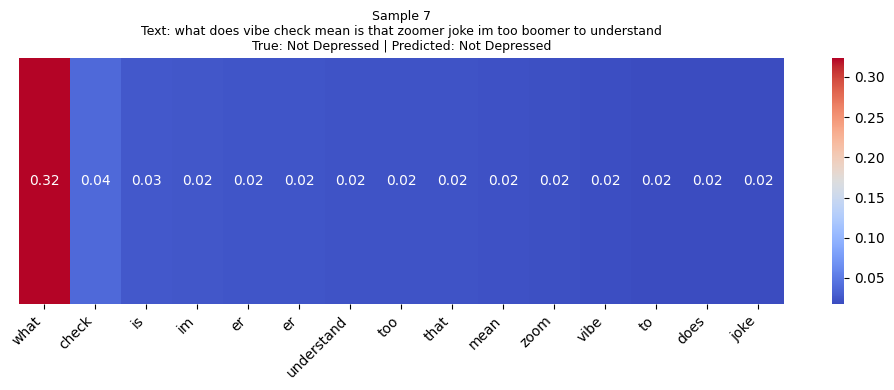

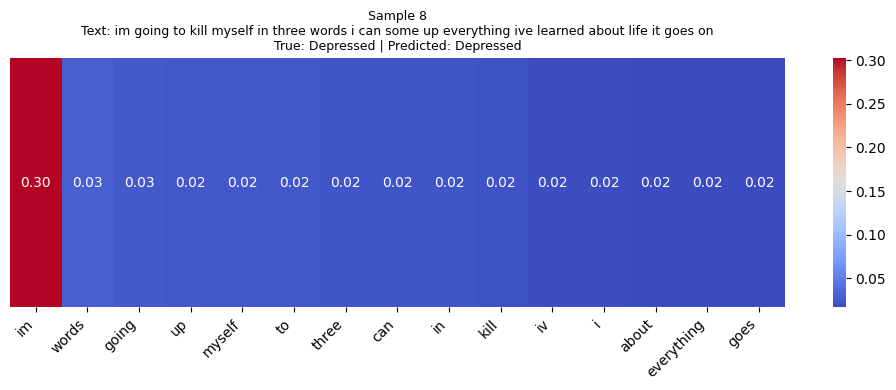

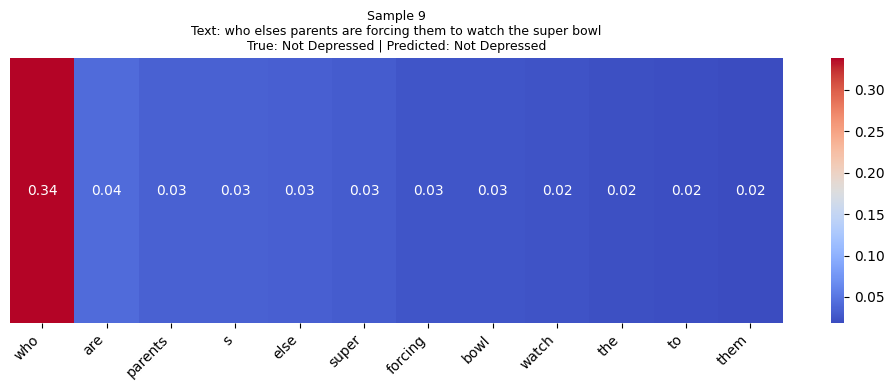

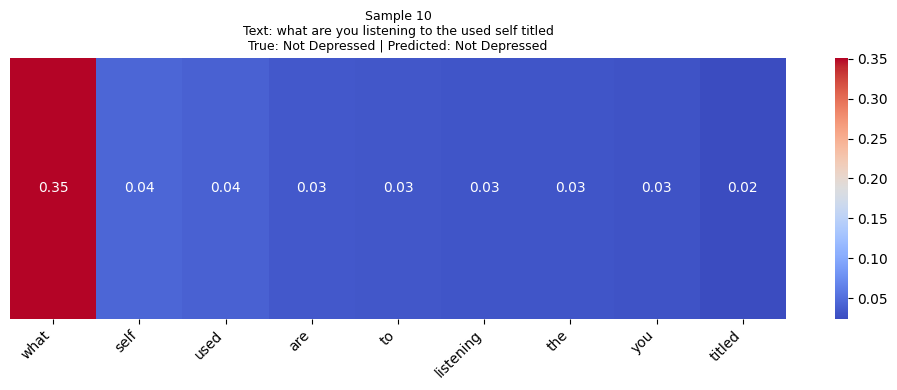

In [50]:
# Block 3: Plot smart clean heatmaps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for i in range(len(sample_texts)):
    tokens = decoded_tokens_list[i]
    attention_scores = cls_attention[i][:len(tokens)]  # crop to non-padding tokens

    # Remove tokens with very low attention (< 0.01)
    filtered_tokens = []
    filtered_attentions = []
    for token, score in zip(tokens, attention_scores):
        if score >= 0.01:
            filtered_tokens.append(token)
            filtered_attentions.append(score)

    # Sort by highest attention
    sorted_indices = np.argsort(filtered_attentions)[::-1]
    top_k = min(15, len(sorted_indices))  # Top 15 tokens
    top_tokens = [filtered_tokens[j] for j in sorted_indices[:top_k]]
    top_attentions = [filtered_attentions[j] for j in sorted_indices[:top_k]]

    # Dynamic figure size
    fig_width = max(10, len(top_tokens) * 0.6)

    plt.figure(figsize=(fig_width, 4))
    sns.heatmap(
        [top_attentions],
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        xticklabels=top_tokens,
        cbar=True
    )

    predicted_label = 'Depressed' if predicted_classes[i] == 1 else 'Not Depressed'
    true_label = 'Depressed' if sample_true_labels[i] == 1 else 'Not Depressed'

    plt.title(
        f"Sample {i+1}\nText: {sample_texts[i][:200]}{'...' if len(sample_texts[i]) > 200 else ''}\nTrue: {true_label} | Predicted: {predicted_label}",
        fontsize=9
    )

    plt.xticks(rotation=45, ha='right')
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [1]:
from lime.lime_text import LimeTextExplainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# تحميل النموذج
model_path = "saved_model_electra"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

class_names = ["Not Depressed", "Depressed"]

# تعريف دالة التنبؤ المناسبة لـ LIME
def predictor(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

# مفسر LIME
explainer = LimeTextExplainer(class_names=class_names)

# الجملة
text = "I want to jump out of a window and die"

# تفسير الجملة
exp = explainer.explain_instance(text, predictor, num_features=10)

# عرض التفسير في Jupyter / Colab
exp.show_in_notebook(text=True)

# حفظ التفسير في HTML
exp.save_to_file('lime_distilbert_explanation.html')

C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node